# Project card

**The paper:** 
>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**
>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**
>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**
> 2-poisson model https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

**Parameters and assumptions:**
> total count of cells = N

**The forward simulation:**
> Monte-Carlo simulation; Grid search to find paramters for 2 poisson

**The parameterization/fitting:**

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

---

## Utils

### Libraries 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize

### Functions

In [30]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def two_poisson(x, alpha, theta, delta):
    return (alpha * poisson(x, theta)) + ((1-alpha) * poisson(x, delta))

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total

def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total

def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

def nll_mix_poisson(parameters, counts):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    mu1, mu2, pi = parameters[0], parameters[1], parameters[2]
    total = 0.0
    for x in counts:
        prob = max(pi * poisson(x, mu1) + (1 - pi) * poisson(x, mu2), 1e-10)  # Avoid log(0)
        total = total - math.log(prob)
    return total

def fit_2_poisson(counts, mu1, mu2, pi):
    flag = True
    for k in pi:
        for j in mu2:
            for i in mu1:
                total = 0
                for m in range(len(lineages)):
                    total += nll_mix_poisson([i*(genome_size_lineages[m])*10**(-7), j*(genome_size_lineages[m])*10**(-7), k], lineages[m])
                nll_mix_poisson_score = total
                if flag:
                    minimum = nll_mix_poisson_score
                    mu1_hat = i
                    mu2_hat = j
                    pi_hat = k
                    flag = False
                elif nll_mix_poisson_score < minimum:
                    minimum = nll_mix_poisson_score
                    mu1_hat = i
                    mu2_hat = j
                    pi_hat = k
    return round(mu1_hat, 3), round(mu2_hat, 3), round(pi_hat, 3)

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32
seed = 100

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def choose(r, probs):
    """The outcome k whose slice of [0, 1) contains r, the slices laid end to end in order. Returns k as a position in probs, from 0."""
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1

def fraction_zero(counts):
    """p0, the fraction of cultures with no resistant colonies at all."""
    empty = 0
    for c in counts:
        if c == 0:
            empty = empty + 1
    return empty / len(counts)

## Main

### 1. Read Files

In [14]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna().astype(int)) for column in df.columns]
counts = [int(y) for x in lineages for y in x]

genome_size = 1.02E+07
genome_size_lineages = [10926041,10034503,10099122,10889177,11040018,9684038,10209723,10826564]

# Print the data
print("Data Matrix:")
print(df,"\n")
print("Lineage Cell Division Counts:")
print("\n".join(str(lin) for lin in lineages), "\n")
print("Flattened Counts:")
print(counts, len(counts))

Data Matrix:
           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

Lineage Cell Division Counts:
[0, 2, 0, 3, 2, 4, 1, 3, 4]
[3, 7, 6, 0, 0, 2, 3, 4, 4, 6, 5, 1, 0]
[2, 2, 0, 3, 0, 0, 1, 1, 4, 5, 3, 0, 9, 4, 2]
[2, 3, 1

### 2. Summary Statistics

Mean: 2.7411764705882353 mutations/cell division
Mean: 2.6874279123414073e-07 mutations/cell division/bp
Standard Deviation: 2.3919125558306864
Variance: 5.721245674740486
Variance is higher than mean, thus overdispersed


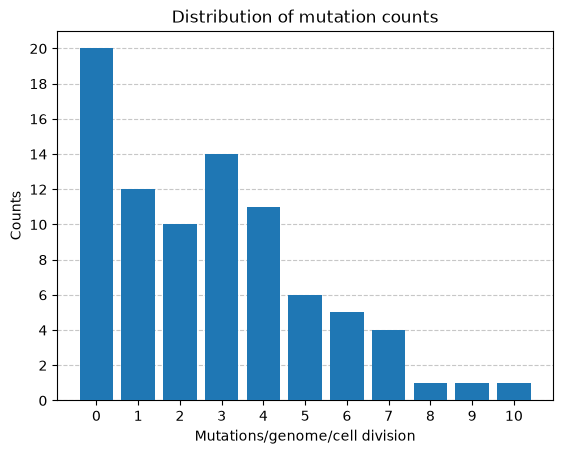

In [15]:
max_mutation_count = max(counts)
mutation_counts = [0] * (max_mutation_count + 1)

for count in counts:
    mutation_counts[count] += 1 

mean_count = mean(counts)
sigma = std_dev(counts)
variance = sigma ** 2
mutation_rate = mean_count/genome_size
print(f"Mean: {mean_count} mutations/cell division")
print(f"Mean: {mutation_rate} mutations/cell division/bp")
print(f"Standard Deviation: {sigma}")
print(f"Variance: {variance}")
print("Variance is higher than mean, thus overdispersed")

# mutation_prob =  [ mutation_count/sum(mutation_counts) for mutation_count in mutation_counts ]

fig, ax = plt.subplots()
ax.bar(range(len(mutation_counts)), mutation_counts, zorder=3)
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,22,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_title("Distribution of mutation counts")
plt.show()

### 3. Models

##### 3.1.1 1-Poisson Model

theta_hat 2.7399999999999998
NLL Score 199.25319597233133
Mean:  2.7411764705882353
NLL Score 199.2531745069619


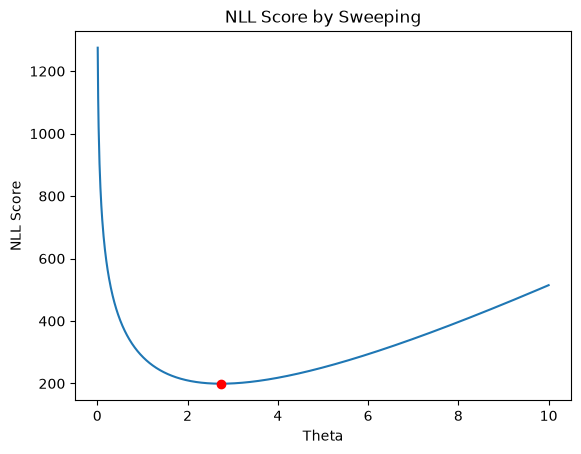

In [16]:
likelihoods = [0] * 1000
nlls = [0] * 1000
thetas = [0] * 1000
theta_start = 0.01
dtheta = 0.01

# print(likelihood(counts, mean_count))
for i in range(len(thetas)):
    thetas[i] = theta_start + (i * dtheta)
    # likelihoods[i] = likelihood(counts, thetas[i])
    nlls[i] = nll(counts, thetas[i])
    
best = position_of_min(nlls)
theta_hat = thetas[best]
best_score = nlls[best]
print("theta_hat", theta_hat)
print("NLL Score", best_score)
print("Mean: ", mean_count)
print("NLL Score", nll(counts, mean_count))

fig, ax = plt.subplots()
ax.plot(thetas, nlls)
ax.plot(theta_hat, best_score, 'ro')
ax.set_xlabel("Theta")
ax.set_ylabel("NLL Score")
ax.set_title("NLL Score by Sweeping")
plt.show()

#### 3.1.2 Monte-Carlo Simulation using 1-Poisson

2.913494809688581 0.07058823529411765 2.7058823529411766
2.5743944636678195 0.047058823529411764 2.8823529411764706
3.2340484429065723 0.047058823529411764 2.9647058823529413
1.8953633217993076 0.047058823529411764 2.6588235294117646
3.096193771626296 0.08235294117647059 2.5294117647058822
2.2499653979238747 0.09411764705882353 2.5058823529411764
3.571764705882353 0.09411764705882353 2.8
2.3894809688581318 0.058823529411764705 2.458823529411765
3.351695501730104 0.1411764705882353 2.5647058823529414
3.256747404844293 0.047058823529411764 2.8823529411764706
2.929273356401385 0.023529411764705882 2.988235294117647
2.694256055363322 0.03529411764705882 2.847058823529412
3.2755709342560557 0.07058823529411765 2.9176470588235293
2.623667820069204 0.03529411764705882 2.847058823529412
2.8116262975778574 0.09411764705882353 2.8117647058823527
2.8323875432525956 0.047058823529411764 2.776470588235294
2.404982698961938 0.047058823529411764 2.6823529411764704
2.0022145328719723 0.035294117647058

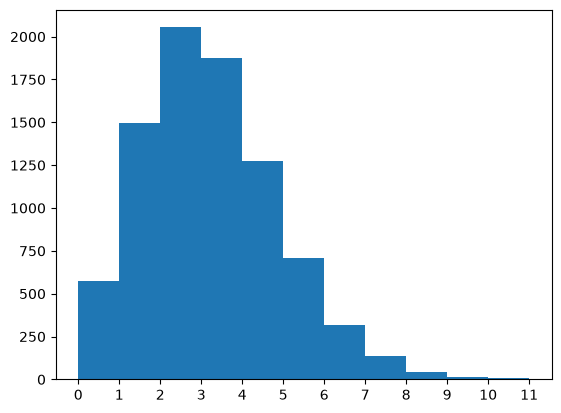

In [17]:
def simuate_count(lam, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = poisson(0, lam)
    k = 0
    while r > total:
        k += 1
        total = total + poisson(k, lam)
    return k, state

cell_divisions = 85
state = seed

def experiment(lam, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count(lam, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

simulated_runs = []

for i in range(100):
    simulated_counts, state = experiment(theta_hat, cell_divisions, state)
    simulated_runs.append(simulated_counts)
    deviation = std_dev(simulated_counts)
    zeros = fraction_zero(simulated_counts)
    print(deviation ** 2, zeros, mean(simulated_counts))
    
fig, ax = plt.subplots()
simulated_runs_flat = [y for x in simulated_runs for y in x]
ax.hist(simulated_runs_flat, bins=range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1))
ax.set_xticks((range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1)))

#### 3.1.3 Backwards - estimating the 1-poisson model’s parameter/s

#### 1-Poisson Model

In [18]:
mu_candidates = np.arange(0.02, 5, 0.02).tolist()            

scores_nll_ = [0.0] * len(mu_candidates)

for i in range(len(mu_candidates)):
  total = 0
  for j in range(len(lineages)):
    total += nll(lineages[j], mu_candidates[i]*(genome_size_lineages[j])*10**(-7))
  scores_nll_[i] = total

position_of_min_nll = position_of_min(scores_nll_)
mu_hat = mu_candidates[position_of_min_nll]
print(f"Estimated mutation rate (mu_hat): {mu_hat} e-7 mutations/cell division/bp")

Estimated mutation rate (mu_hat): 2.62 e-7 mutations/cell division/bp


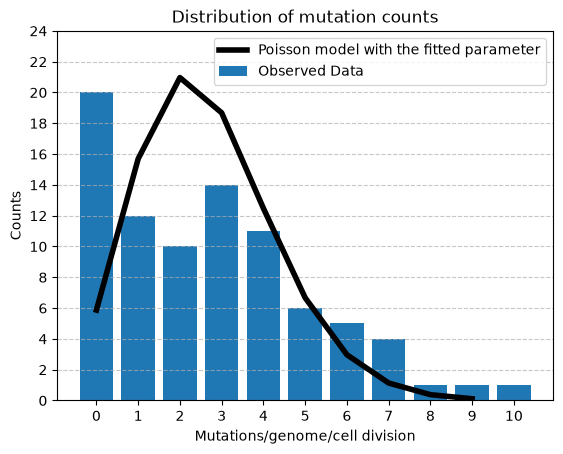

In [19]:
k_counts = range(max_mutation_count)
y = [0] * len(k_counts)
for i in range(len(k_counts)):
    y[i] += poisson(k_counts[i], mu_hat*genome_size*10**(-7))

y = [n * 85 for n in y]
plt.plot(k_counts, y,color="black", label="Poisson model with the fitted parameter",linewidth=4)
plt.bar(range(len(mutation_counts)), mutation_counts, label="Observed Data")
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11))
plt.yticks(range(0,25,2))
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### 3.2 Monte Carlo for 2-Poisson Model 

5.722352941176471 20.0 2.6
5.494256055363324 15.000000000000002 2.847058823529412
6.422975778546714 22.000000000000004 2.976470588235294
4.102975778546713 20.0 2.4235294117647057
6.122629757785464 29.0 2.3176470588235296
4.3659515570934255 20.0 2.3411764705882354
6.556401384083047 25.0 2.764705882352941
4.824083044982701 27.0 2.3058823529411763
5.8693425605536325 26.000000000000004 2.4352941176470586
6.871141868512107 23.0 2.8941176470588235
6.1281660899653945 21.0 2.9647058823529413
5.303252595155711 18.0 2.7294117647058824
6.481107266435989 20.0 2.9647058823529413
5.548235294117645 20.0 2.8
5.36968858131488 18.0 2.9176470588235293
5.914740484429068 25.0 2.776470588235294
5.307958477508647 22.000000000000004 2.4705882352941178
4.083598615916954 16.0 2.6588235294117646
6.714740484429066 25.0 2.776470588235294
4.368166089965398 19.0 2.764705882352941
5.242076124567475 16.0 2.8705882352941177
6.06837370242214 21.0 2.7529411764705882
5.120276816609003 19.0 2.7176470588235295
5.05937716262

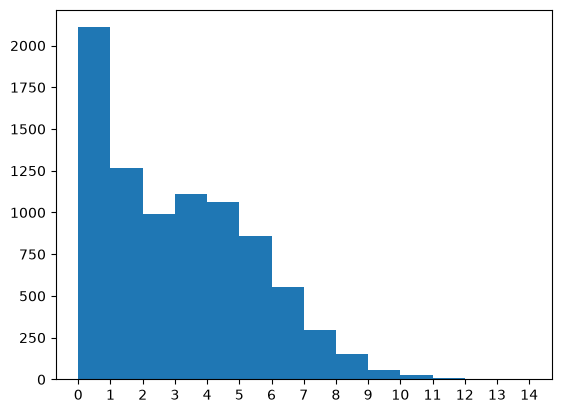

In [46]:
def simuate_count(alpha, lam, delta, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = two_poisson(0, alpha, lam, delta)
    k = 0
    while r > total:
        k += 1
        total = total + two_poisson(k, alpha, lam, delta)
    return k, state

cell_divisions = 85
state = seed

def experiment(alpha, lam, delta, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count(alpha, lam, delta, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

simulated_runs = []

for i in range(100):
    simulated_counts, state = experiment(0.35, 0.402, 3.897, cell_divisions, state)
    simulated_runs.append(simulated_counts)
    deviation = std_dev(simulated_counts)
    zeros = fraction_zero(simulated_counts) * 85
    print(deviation ** 2, zeros, mean(simulated_counts))
    
fig, ax = plt.subplots()
simulated_runs_flat = [y for x in simulated_runs for y in x]
ax.hist(simulated_runs_flat, bins=range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1))
ax.set_xticks((range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1)))

#### 2-Poisson Model Backwards estimate

In [20]:
mu1_candidates = np.arange(0, 2, 0.02).tolist()
mu2_candidates = np.arange(1 , 5, 0.02).tolist()
pi_candidates = np.arange(0.05 , 0.95, 0.05).tolist()

mu1_hat, mu2_hat, pi_hat = fit_2_poisson(counts, mu1_candidates, mu2_candidates, pi_candidates)

print("mu1_hat =", round(mu1_hat, 3),"e-7 mutations/cell division/bp")
print("mu2_hat =", round(mu2_hat, 3),"e-7 mutations/cell division/bp")
print("pi_hat =", round(pi_hat*100, 3), "%")

mu1_hat = 0.44 e-7 mutations/cell division/bp
mu2_hat = 3.8 e-7 mutations/cell division/bp
pi_hat = 35.0 %


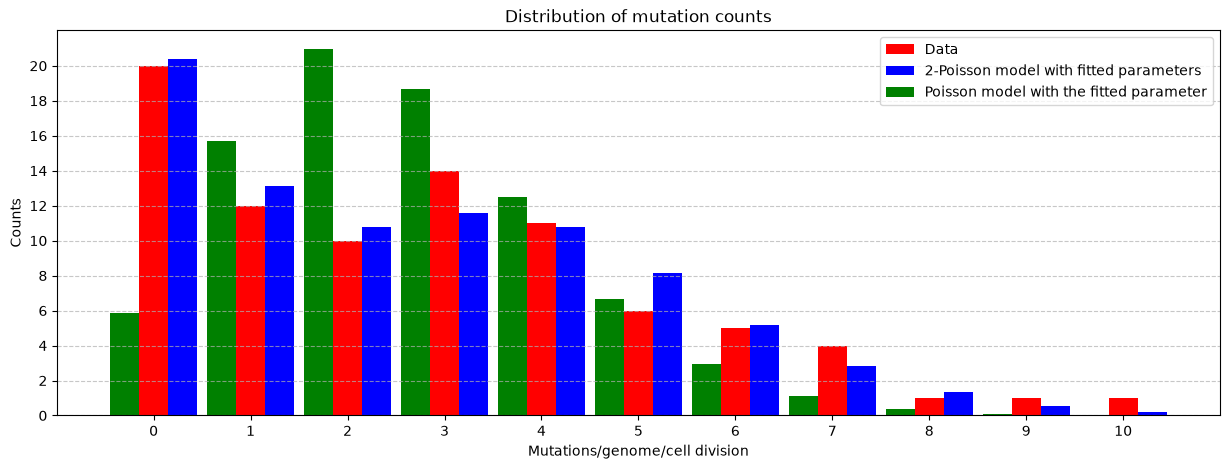

In [21]:
y_mix_poisson_lik = [0] * len(counts)
y_mix_poisson_test = [0] * len(counts)

for i in range(len(counts)):
    y_mix_poisson_lik[i] += pi_hat * poisson(counts[i], mu1_hat) + (1-pi_hat) * poisson(counts[i], mu2_hat)
    y_mix_poisson_test[i] += 0.35 * poisson(counts[i], 0.5) + (1-0.35) * poisson(counts[i], 3.5)
    #y_mix_poisson_test[i] += 0.2 * poisson(counts[i], mu1_hat) + (1-0.2) * poisson(counts[i], mu2_hat)

N = 85
y_mix_poisson_lik = [x*N for x in y_mix_poisson_lik]
y_mix_poisson_test = [x*N for x in y_mix_poisson_test]

plt.figure(figsize=(15, 5))
#plt.bar(counts, y_mix_poisson)
plt.bar(np.array(range((max_mutation_count)+1)), mutation_counts, width=0.3, label='Data', color='red')
plt.bar(np.array(counts) + 0.3, y_mix_poisson_lik, width=0.3, label='2-Poisson model with fitted parameters', color='blue')
plt.bar(np.array(k_counts) - 0.3, y,color="green", label="Poisson model with the fitted parameter", width=0.3)
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### Comparing models with AIC

In [22]:
AIC_1_Poisson = 2 * 1 + 2 * scores_nll_[position_of_min_nll]
AIC_2_Poisson = 2 * 3 + 2 * nll_mix_poisson([mu1_hat, mu2_hat, pi_hat], counts)
print("AIC for 1-Poisson model:", round(AIC_1_Poisson,2))
print("AIC for 2-Poisson model:", round(AIC_2_Poisson,2))

AIC for 1-Poisson model: 402.12
AIC for 2-Poisson model: 364.22


### Parameter uncertainty

#### Curvature error bar

In [23]:
result = minimize(nll_mix_poisson, [mu1_hat, mu2_hat, pi_hat], args=(counts,), method='BFGS')

if result.success:
    best_parameters = result.x

    #'hess_inv' is the inverse of the Hessian (Covariance Matrix)
    covariance_matrix = result.hess_inv

    #The square roots of the diagonal are the Standard Errors (uncertainty)
    standard_errors = np.sqrt(np.diag(covariance_matrix))

    print("--- FINAL OPTIMIZED RESULTS ---")
    print(f"mu_1 (i): {best_parameters[0]:.4f} (Uncertainty: ±{standard_errors[0]:.4f})")
    print(f"mu_2 (j): {best_parameters[1]:.4f} (Uncertainty: ±{standard_errors[1]:.4f})")
    print(f"proportion pi (k): {best_parameters[2]:.4f} (Uncertainty: ±{standard_errors[2]:.4f})")
else:
    print("The optimizer could not refine the parameters. Check whether your initial data is well written.")

--- FINAL OPTIMIZED RESULTS ---
mu_1 (i): 0.4019 (Uncertainty: ±0.2380)
mu_2 (j): 3.8967 (Uncertainty: ±0.3503)
proportion pi (k): 0.3306 (Uncertainty: ±0.0803)


#### Bootstrap method

In [24]:
B = 2000                                          
SEED = 26546
rs = uniforms(B * N, SEED)                        
equal = [1 / N] * N                               

boot_estimates = [0.0] * B
for b in range(B):
  resample = [0.0] * N
  for i in range(N):
    j = choose(rs[b*N + i], equal)
    resample[i] = counts[j]
    boot_estimates[b] = mean(resample)
sigma_boot = std_dev(boot_estimates)
print(f"Bootstrap estimate of standard error: {round(sigma_boot, 3)} mutations/genome/cell division")

Bootstrap estimate of standard error: 0.254 mutations/genome/cell division


#### Likelihood interval method 

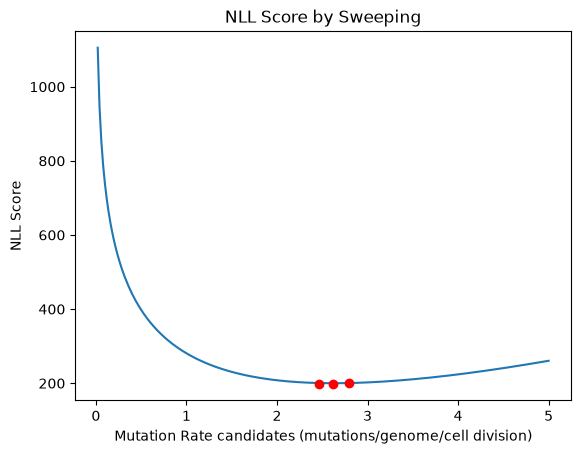

Likelihood interval: 2.46 to 2.8 counts per cell, half-width 0.17 mutations/genome/cell division


In [25]:
low = mu_hat
high = mu_hat
for i in range(len(scores_nll_)):
  if scores_nll_[i] <= scores_nll_[position_of_min_nll] + 0.5:
    if mu_candidates[i] < low:
      low = mu_candidates[i]
    if mu_candidates[i] > high:
      high = mu_candidates[i]

fig, ax = plt.subplots()
ax.plot(mu_candidates, scores_nll_)
ax.plot(mu_hat, best_score, 'ro')
ax.plot(low, best_score -0.5, 'ro')
ax.plot(high, best_score +0.5, 'ro')
ax.set_xlabel("Mutation Rate candidates (mutations/genome/cell division)")
ax.set_ylabel("NLL Score")
ax.set_title("NLL Score by Sweeping")
plt.show()

print("Likelihood interval:", low, "to", round(high, 3), "counts per cell, half-width", round((high - low) / 2, 3),"mutations/genome/cell division")